# Mean-Variance Portfolio Optimization with Real Crypto Data

**Question:** Harry Markowitz (1952) showed that an investor who cares only about expected return and variance should hold a portfolio on the *efficient frontier* — the set of portfolios with the lowest risk for each level of return. How does that frontier look for a basket of real cryptocurrencies, and how much of the "optimal" portfolio survives when we use it on data it has not seen?

This notebook:
1. Downloads daily Binance prices for 8 large cryptocurrencies with `src/data.py`.
2. Builds intuition from one asset (mean and variance) to two assets (correlation and diversification) to many assets (the covariance matrix).
3. Traces the efficient frontier three ways: random portfolios, the closed-form unconstrained frontier, and a long-only numerical optimizer.
4. Finds the global minimum-variance portfolio and the maximum-Sharpe (tangency) portfolio, and draws the capital market line.
5. Stress-tests the result: how sensitive the weights are to the input estimates, and how the portfolios perform out-of-sample.

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(42)

ANN = 365     # crypto trades every day of the year
RF = 0.04     # annual risk-free rate used for Sharpe ratios

## 1. Data: 8 large cryptocurrencies from Binance

`src/data.py` downloads daily OHLCV candles through [ccxt](https://github.com/ccxt/ccxt) and saves one CSV per pair in `src/data/`. The notebook runs it with a fixed date range (`--since`/`--until`) and `--full`, so every run sees the same history and the results are reproducible. If the download fails (no network), the cell falls back to whatever CSVs are already in `src/data/`.

All eight coins traded on Binance against USDT for the whole window, which starts on 2021-01-01. We use the daily **close**.

In [2]:
# src/ sits next to the topic folders: one level up in the repo, two levels up locally (W*/<Topic>/)
SRC = next(p / "src" for p in Path.cwd().resolve().parents if (p / "src" / "data.py").exists())
SYMBOLS = ["BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT",
           "XRP/USDT", "ADA/USDT", "DOGE/USDT", "LINK/USDT"]
START, END = "2021-01-01", "2026-10-01"

cmd = [sys.executable, str(SRC / "data.py"), *SYMBOLS,
       "--since", START, "--until", END, "--full"]
result = subprocess.run(cmd, capture_output=True, text=True)
if result.returncode == 0:
    # drop the trailing "→ <local path>" so the output does not expose the machine's directory layout
    print("\n".join(l.rsplit(" → ", 1)[0] for l in result.stdout.splitlines() if "saved" in l))
else:
    print("Download failed, using existing CSVs in src/data:\n", result.stderr[-500:])


def load_close(symbol):
    path = SRC / "data" / f"BINANCE_{symbol.replace('/', '-')}_1d.csv"
    df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
    return df["Close"].rename(symbol.split("/")[0])


prices = pd.concat([load_close(s) for s in SYMBOLS], axis=1).loc[START:END].dropna()
print(f"\n{prices.shape[1]} assets, {len(prices)} days: {prices.index[0].date()} → {prices.index[-1].date()}")
prices.tail()

  BTC/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  ETH/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  BNB/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  SOL/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  XRP/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  ADA/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  DOGE/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00
  LINK/USDT: saved 2099 candles (2099 new) 2021-01-01 00:00:00 → 2026-09-30 00:00:00

8 assets, 2099 days: 2021-01-01 → 2026-09-30


,BTC,ETH,BNB,SOL,XRP,ADA,DOGE,LINK
Date,,,,,,,,
2026-09-26,84433.10,2696.33,773.59,121.41,1.5274,0.2540,0.09673,14.146
2026-09-27,84472.00,2688.65,778.90,121.99,1.5167,0.2551,0.09690,14.024
2026-09-28,83500.01,2688.71,763.96,118.89,1.4968,0.2473,0.09396,15.452
2026-09-29,83663.66,2677.98,758.66,119.15,1.4906,0.2445,0.09389,14.607
2026-09-30,83623.60,2686.01,769.27,118.12,1.4900,0.2466,0.09456,14.366


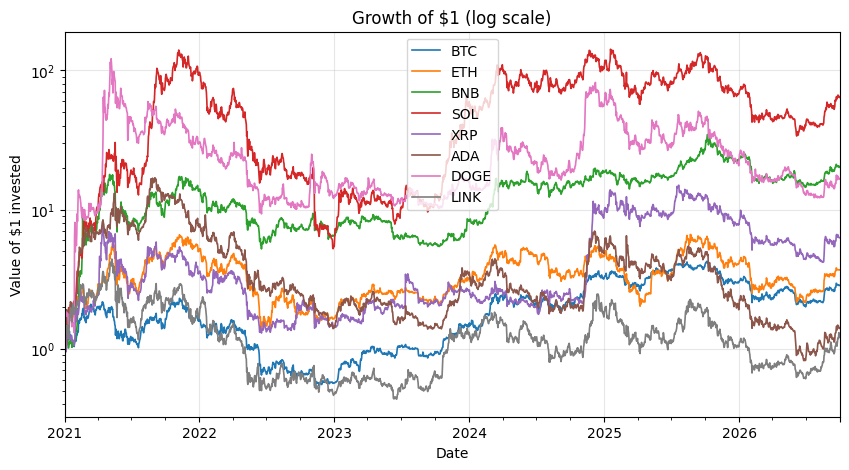

In [3]:
ax = (prices / prices.iloc[0]).plot(logy=True, figsize=(10, 5), lw=1.2)
ax.set_title("Growth of $1 (log scale)")
ax.set_ylabel("Value of $1 invested")
plt.show()

## 2. One asset: mean and variance

For a price series $P_t$ the daily **simple return** is $r_t = P_t / P_{t-1} - 1$. We use simple rather than log returns because a portfolio's simple return is exactly the weighted sum of its assets' simple returns, which is what makes the portfolio formulas below linear in the weights.

For each asset we estimate

$$ \hat\mu = \frac{1}{T}\sum_t r_t, \qquad \hat\sigma^2 = \frac{1}{T-1}\sum_t (r_t - \hat\mu)^2 $$

and annualize with 365 trading days: $\mu_{ann} = 365\,\hat\mu$, $\sigma_{ann} = \sqrt{365}\,\hat\sigma$. The **Sharpe ratio** $(\mu_{ann} - r_f)/\sigma_{ann}$ is the excess return earned per unit of risk.

,Ann. mean,Ann. vol,Sharpe
SOL,1.31,1.09,1.17
BNB,0.83,0.81,0.99
DOGE,1.59,2.05,0.76
XRP,0.79,1.00,0.75
ETH,0.52,0.77,0.63
BTC,0.35,0.57,0.53
ADA,0.52,0.98,0.49
LINK,0.52,0.98,0.48


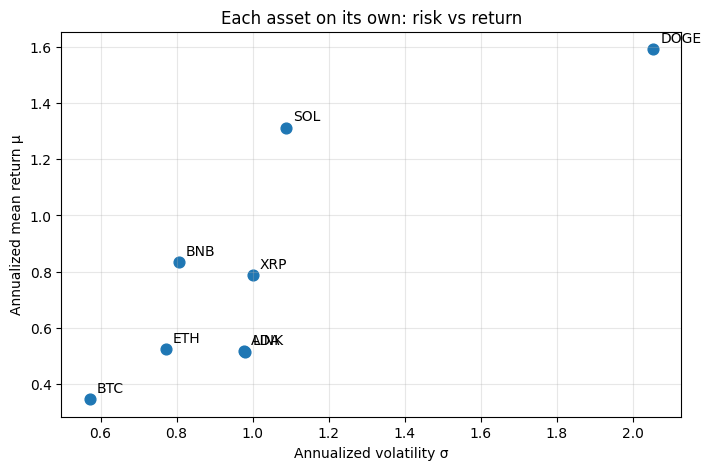

In [6]:
returns = prices.pct_change().dropna()
mu = returns.mean() * ANN
sigma = returns.std() * np.sqrt(ANN)

stats = pd.DataFrame({"Ann. mean": mu, "Ann. vol": sigma, "Sharpe": (mu - RF) / sigma})
display(stats.sort_values("Sharpe", ascending=False).style.format("{:.2f}"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sigma, mu, s=60)
for name in mu.index:
    ax.annotate(name, (sigma[name], mu[name]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Annualized volatility σ")
ax.set_ylabel("Annualized mean return μ")
ax.set_title("Each asset on its own: risk vs return")
plt.show()

Every coin has an annualized volatility far above what equities show (roughly 15–20% for a stock index). Over this window the riskier coins also earned higher mean returns, but not in proportion: Sharpe ratios range from about 0.5 (BTC, ADA, LINK) to above 1 (SOL), so some coins paid much more per unit of risk than others. Note that $\hat\mu$ is an *arithmetic* mean: with volatility this high, the compounded growth in the chart above is much lower than the arithmetic mean suggests, roughly $\mu - \sigma^2/2$.

## 3. Two assets: where diversification comes from

With weight $w$ in asset 1 and $1-w$ in asset 2:

$$ \mu_p = w\mu_1 + (1-w)\mu_2 $$
$$ \sigma_p^2 = w^2\sigma_1^2 + (1-w)^2\sigma_2^2 + 2w(1-w)\,\rho_{12}\,\sigma_1\sigma_2 $$

The mean is a straight-line blend, but the variance is not: whenever the correlation $\rho_{12} < 1$, the portfolio's volatility is *below* the weighted average of the two volatilities. That gap is the free lunch of diversification.

Below, BTC and ETH use their real $\mu$ and $\sigma$; we then redraw the curve with different hypothetical correlations to see how much the shape depends on $\rho$.

In [9]:
a, b = "BTC", "ETH"
rho_real = returns[a].corr(returns[b])
w = np.linspace(0, 1, 101)

In [10]:
w

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

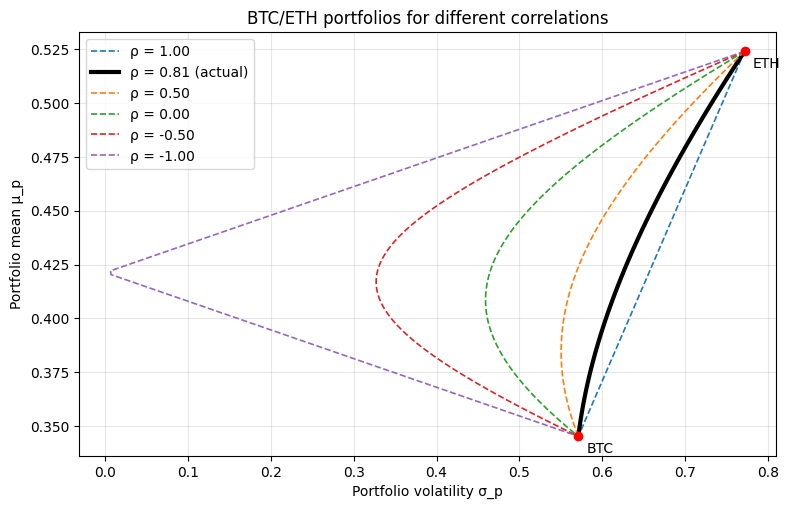

Actual daily-return correlation BTC–ETH: 0.81


In [ ]:
a, b = "BTC", "ETH"
rho_real = returns[a].corr(returns[b])
w = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(9, 5.5))
for rho in [1.0, rho_real, 0.5, 0.0, -0.5, -1.0]:
    mp = w * mu[a] + (1 - w) * mu[b]
    vp = (w**2 * sigma[a]**2 + (1 - w)**2 * sigma[b]**2
          + 2 * w * (1 - w) * rho * sigma[a] * sigma[b])
    style = dict(lw=3, color="k") if rho == rho_real else dict(lw=1.2, ls="--")
    ax.plot(np.sqrt(vp), mp, label=f"ρ = {rho:.2f}" + (" (actual)" if rho == rho_real else ""), **style)
ax.scatter([sigma[a], sigma[b]], [mu[a], mu[b]], color="red", zorder=5)
for n in (a, b):
    ax.annotate(n, (sigma[n], mu[n]), xytext=(6, -12), textcoords="offset points")
ax.set_xlabel("Portfolio volatility σ_p")
ax.set_ylabel("Portfolio mean μ_p")
ax.set_title(f"{a}/{b} portfolios for different correlations")
ax.legend()
plt.show()
print(f"Actual daily-return correlation {a}–{b}: {rho_real:.2f}")

**How to read it.** Each curve is every BTC/ETH mix from 100% ETH to 100% BTC, and each point on a curve is one portfolio. Moving left means less risk, moving up means more return. The two red dots (the single coins) are the same on every curve; only the path between them changes.

* At $\rho = 1$ the curve is a straight line: a 50/50 mix has exactly the average of the two volatilities, so there is no diversification at all.
* As $\rho$ falls the curve bends further left: the same mix, with the same expected return, carries less risk. How far a curve bulges left of the straight line is the diversification benefit.
* At $\rho = -1$ it touches zero volatility: one coin's losses exactly offset the other's gains.
* Once $\rho$ is low enough (below $\sigma_{low}/\sigma_{high}$, the ratio of the two volatilities), part of the curve lies to the left of *both* coins: a mix can be less risky than its least risky part, which the straight line can never do.

**What it shows here.** The real BTC–ETH correlation is about 0.8, so the black curve sits close to the straight $\rho = 1$ line and bends only a little — the two coins mostly move together, and combining them removes little risk. The dashed curves show what we are missing: a diversifier with $\rho$ near 0 would cut risk far more. That is why the next step looks at correlations across *all* the coins.

## 4. Many assets: the covariance matrix

With a weight vector $w$ (summing to 1), expected returns $\mu$ and covariance matrix $\Sigma$:

$$ \mu_p = w^\top\mu, \qquad \sigma_p^2 = w^\top\Sigma\,w = \sum_i\sum_j w_i w_j \sigma_i \sigma_j \rho_{ij}. $$

With $N$ assets there are $N$ variances but $N(N-1)/2$ covariances, so for a large portfolio the **covariances dominate** the risk. The correlation heatmap shows how much room there is to diversify within crypto.

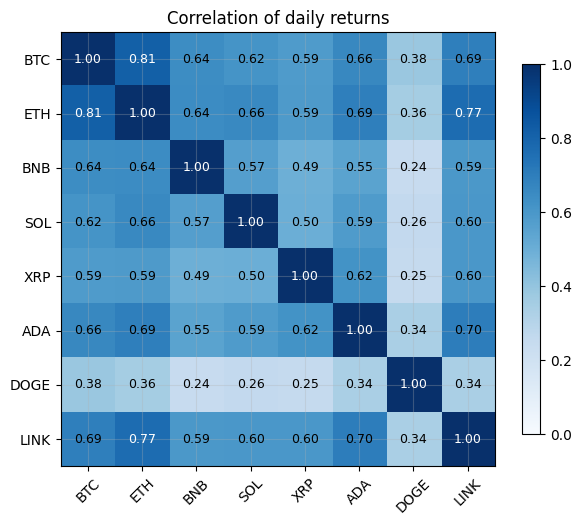

Average pairwise correlation: 0.55 (min 0.24, max 0.81)


In [6]:
corr = returns.corr()
cov = returns.cov() * ANN
names = list(returns.columns)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=45)
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if corr.iloc[i, j] > 0.7 else "black", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of daily returns")
plt.show()

off_diag = corr.values[~np.eye(len(names), dtype=bool)]
print(f"Average pairwise correlation: {off_diag.mean():.2f} (min {off_diag.min():.2f}, max {off_diag.max():.2f})")

## 5. Random portfolios: the feasible set

Before optimizing anything, draw 20,000 random long-only portfolios (weights from a Dirichlet distribution, so they are positive and sum to 1) and plot each one's risk and return. The cloud is the **feasible set**; its upper-left edge is the efficient frontier we are about to compute exactly.

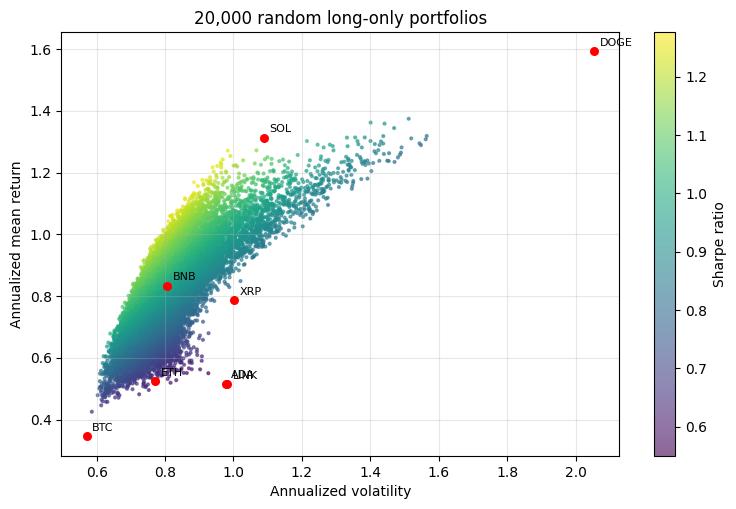

In [7]:
mu_v, cov_v = mu.values, cov.values


def port_stats(w, mu_v=mu_v, cov_v=cov_v):
    ret = w @ mu_v
    vol = np.sqrt(w @ cov_v @ w)
    return ret, vol, (ret - RF) / vol


W_rand = RNG.dirichlet(np.ones(len(names)), size=20_000)
rand = np.array([port_stats(w) for w in W_rand])

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(rand[:, 1], rand[:, 0], c=rand[:, 2], cmap="viridis", s=4, alpha=0.6)
fig.colorbar(sc, ax=ax, label="Sharpe ratio")
ax.scatter(sigma, mu, color="red", s=30, zorder=5)
for n in names:
    ax.annotate(n, (sigma[n], mu[n]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized mean return")
ax.set_title("20,000 random long-only portfolios")
plt.show()

## 6. The efficient frontier

Markowitz's problem: for each target return $m$, find the portfolio with the smallest variance,

$$ \min_w \; w^\top\Sigma w \quad \text{s.t.} \quad w^\top\mu = m, \quad w^\top\mathbf{1} = 1 \;\; (\text{and } w \ge 0 \text{ if no short selling}). $$

**Unconstrained (short selling allowed)** — the problem has a closed-form solution. With
$A = \mathbf{1}^\top\Sigma^{-1}\mathbf{1}$, $B = \mathbf{1}^\top\Sigma^{-1}\mu$, $C = \mu^\top\Sigma^{-1}\mu$ and $D = AC - B^2$, the frontier is the hyperbola

$$ \sigma^2(m) = \frac{A m^2 - 2Bm + C}{D}. $$

**Long-only** — the $w \ge 0$ constraint has no closed form, so we solve it numerically (SLSQP) for a grid of target returns. Because it is more constrained, the long-only frontier always lies on or to the right of the unconstrained one.

In [8]:
ones = np.ones(len(names))
inv = np.linalg.inv(cov_v)
A, B, C = ones @ inv @ ones, ones @ inv @ mu_v, mu_v @ inv @ mu_v
D = A * C - B**2

m_grid = np.linspace(mu_v.min(), mu_v.max(), 60)
vol_unconstrained = np.sqrt((A * m_grid**2 - 2 * B * m_grid + C) / D)

bounds = [(0, 1)] * len(names)
sum_to_one = {"type": "eq", "fun": lambda w: w.sum() - 1}
w0 = ones / len(names)


def min_variance(target):
    cons = [sum_to_one, {"type": "eq", "fun": lambda w: w @ mu_v - target}]
    res = minimize(lambda w: w @ cov_v @ w, w0, bounds=bounds, constraints=cons, method="SLSQP")
    return res.x if res.success else None


frontier = [(m, np.sqrt(w @ cov_v @ w)) for m in m_grid if (w := min_variance(m)) is not None]
f_ret, f_vol = np.array(frontier).T
print(f"Long-only frontier: {len(frontier)} of {len(m_grid)} target returns solved")

Long-only frontier: 60 of 60 target returns solved


### Two special portfolios

* **Global minimum variance (GMV)** — the leftmost point of the frontier. It uses only $\Sigma$, not $\mu$. Unconstrained, it has the closed form $w_{GMV} = \Sigma^{-1}\mathbf{1} / (\mathbf{1}^\top\Sigma^{-1}\mathbf{1})$.
* **Tangency (maximum Sharpe)** — the frontier portfolio with the highest $(\mu_p - r_f)/\sigma_p$. Combining it with the risk-free asset gives the **capital market line** (CML), $\mu = r_f + \text{Sharpe}_{tan}\,\sigma$, which beats every other frontier portfolio. Under Tobin's separation theorem every mean-variance investor holds the same tangency portfolio and adjusts risk only by mixing it with cash.

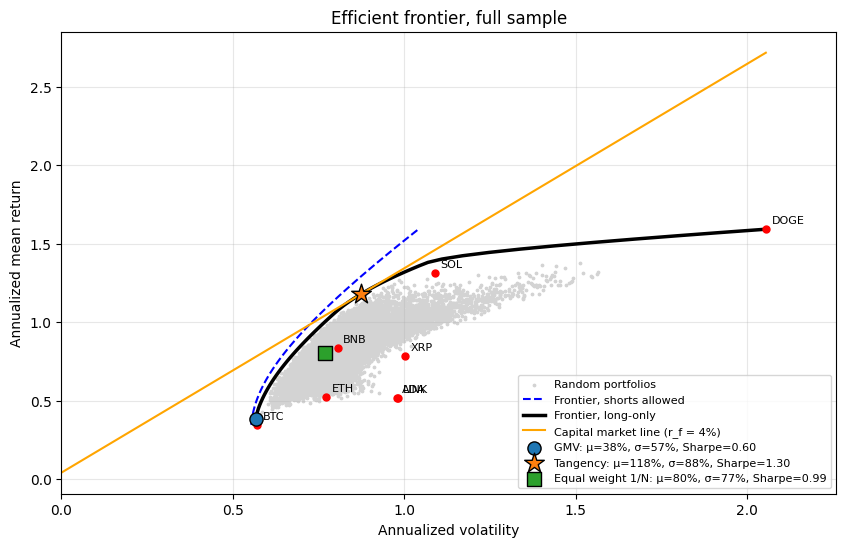

In [9]:
def gmv_weights(cov_v):
    res = minimize(lambda w: w @ cov_v @ w, w0, bounds=bounds,
                   constraints=[sum_to_one], method="SLSQP")
    return res.x


def tangency_weights(mu_v, cov_v):
    neg_sharpe = lambda w: -(w @ mu_v - RF) / np.sqrt(w @ cov_v @ w)
    res = minimize(neg_sharpe, w0, bounds=bounds, constraints=[sum_to_one], method="SLSQP")
    return res.x


w_gmv = gmv_weights(cov_v)
w_tan = tangency_weights(mu_v, cov_v)
w_eq = w0

points = {"GMV": w_gmv, "Tangency": w_tan, "Equal weight 1/N": w_eq}
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rand[:, 1], rand[:, 0], c="lightgray", s=3, label="Random portfolios")
ax.plot(vol_unconstrained, m_grid, "b--", lw=1.5, label="Frontier, shorts allowed")
ax.plot(f_vol, f_ret, "k-", lw=2.5, label="Frontier, long-only")

tan_ret, tan_vol, tan_sharpe = port_stats(w_tan)
x = np.linspace(0, f_vol.max(), 50)
ax.plot(x, RF + tan_sharpe * x, color="orange", lw=1.5, label=f"Capital market line (r_f = {RF:.0%})")

for (label, w), marker in zip(points.items(), ["o", "*", "s"]):
    r, v, s = port_stats(w)
    ax.scatter(v, r, s=220 if marker == "*" else 90, marker=marker, zorder=5,
               edgecolor="k", label=f"{label}: μ={r:.0%}, σ={v:.0%}, Sharpe={s:.2f}")
ax.scatter(sigma, mu, color="red", s=25, zorder=4)
for n in names:
    ax.annotate(n, (sigma[n], mu[n]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlim(0, sigma.max() * 1.1)
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized mean return")
ax.set_title("Efficient frontier, full sample")
ax.legend(loc="lower right", fontsize=8)
plt.show()

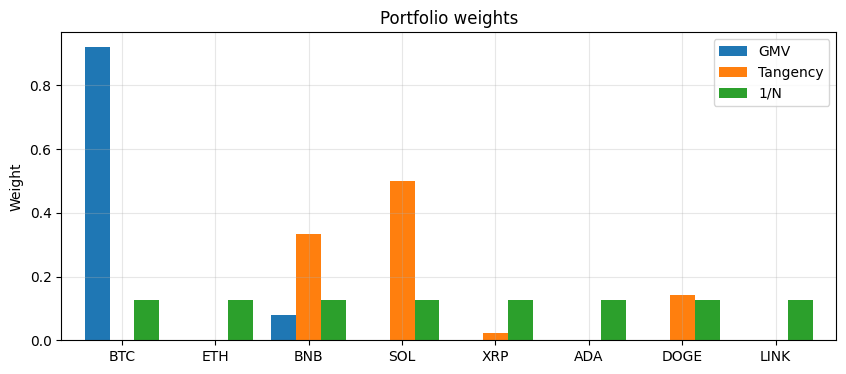

,GMV,Tangency,1/N
BTC,92.0%,0.0%,12.5%
ETH,0.0%,0.0%,12.5%
BNB,8.0%,33.4%,12.5%
SOL,0.0%,50.0%,12.5%
XRP,0.0%,2.3%,12.5%
ADA,0.0%,0.0%,12.5%
DOGE,0.0%,14.3%,12.5%
LINK,0.0%,0.0%,12.5%


In [10]:
weights = pd.DataFrame({"GMV": w_gmv, "Tangency": w_tan, "1/N": w_eq}, index=names)
ax = weights.plot.bar(figsize=(10, 4), width=0.8)
ax.set_ylabel("Weight")
ax.set_title("Portfolio weights")
plt.xticks(rotation=0)
plt.show()
display(weights.style.format("{:.1%}"))

The optimizer is happy to put zero weight on most coins. GMV is almost entirely BTC, the least volatile coin, with a little BNB; because every other coin is both more volatile and highly correlated with BTC, adding them raises risk. The tangency portfolio instead concentrates in the coins with the best historical risk-adjusted returns (SOL and BNB) plus a slice of DOGE. Both are only as good as the $\mu$ and $\Sigma$ we feed them — which is the next question.

## 7. How fragile are the weights? Bootstrap the inputs

Our $\hat\mu$ and $\hat\Sigma$ are estimates from one historical path. To see how much the optimal weights depend on that particular path, resample the daily returns with replacement (a bootstrap), re-estimate $\mu$ and $\Sigma$, and re-optimize — 200 times. If the weights were robust, the boxes below would be narrow.

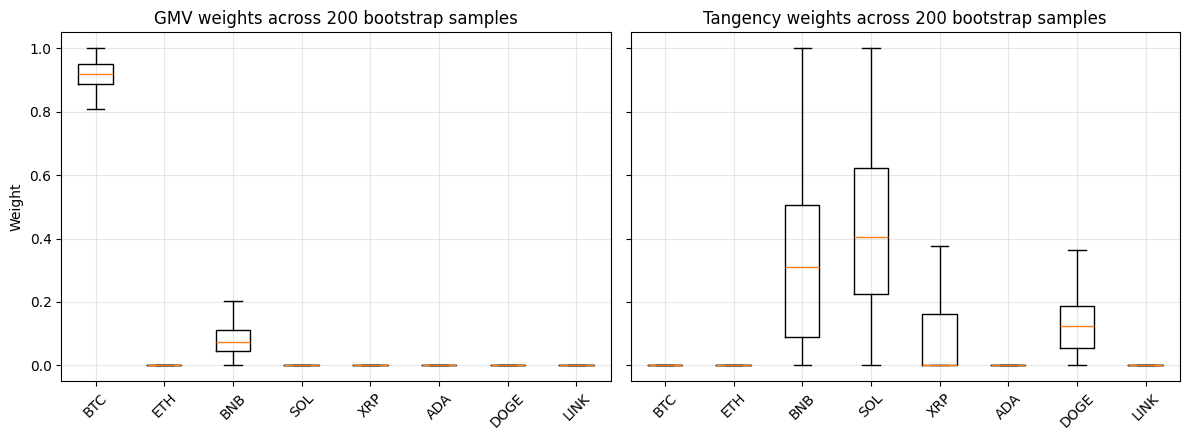

,GMV std of weight,Tangency std of weight
BTC,4.8%,3.0%
ETH,0.0%,1.3%
BNB,4.8%,25.3%
SOL,0.0%,26.5%
XRP,0.6%,15.6%
ADA,0.0%,4.3%
DOGE,0.0%,10.4%
LINK,0.0%,5.6%


In [11]:
n_boot = 200
boot_tan, boot_gmv = [], []
R = returns.values
for _ in range(n_boot):
    sample = R[RNG.integers(0, len(R), len(R))]
    mu_b = sample.mean(axis=0) * ANN
    cov_b = np.cov(sample, rowvar=False) * ANN
    boot_tan.append(tangency_weights(mu_b, cov_b))
    boot_gmv.append(gmv_weights(cov_b))
boot_tan = pd.DataFrame(boot_tan, columns=names)
boot_gmv = pd.DataFrame(boot_gmv, columns=names)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, title in [(axes[0], boot_gmv, "GMV weights"), (axes[1], boot_tan, "Tangency weights")]:
    ax.boxplot(df.values, labels=names, showfliers=False)
    ax.set_title(f"{title} across {n_boot} bootstrap samples")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Weight")
plt.tight_layout()
plt.show()

spread = pd.DataFrame({"GMV std of weight": boot_gmv.std(), "Tangency std of weight": boot_tan.std()})
display(spread.style.format("{:.1%}"))

The GMV weights move relatively little, because they depend only on $\Sigma$, and covariances are estimated far more precisely than means. The tangency weights swing much more widely: a small change in which days happened to be sampled changes the estimated means enough to move whole chunks of the portfolio from one coin to another. This is why Michaud (1989) called mean-variance optimizers "estimation-error maximizers" — they put the most weight exactly where the estimate is most flattering, which is often where it is most wrong.

## 8. Out-of-sample test

The honest test: estimate $\mu$ and $\Sigma$ on **2021–2023 only**, build the three portfolios, then hold those weights (rebalanced daily to the target weights) from **2024 onward** and compare what each portfolio *promised* in-sample with what it *delivered*.

,Pred. μ,Real. μ,Pred. σ,Real. σ,Pred. Sharpe,Real. Sharpe,Max drawdown
Portfolio,,,,,,,
GMV,34.4%,36.1%,64.9%,47.1%,0.47,0.68,-53.0%
Tangency,209.2%,39.2%,114.3%,70.9%,1.80,0.50,-70.2%
1/N,120.1%,37.0%,87.1%,63.9%,1.33,0.52,-67.3%


,GMV,Tangency,1/N
BTC,98.6%,0.0%,12.5%
ETH,0.0%,0.0%,12.5%
BNB,1.4%,16.5%,12.5%
SOL,0.0%,67.8%,12.5%
XRP,0.0%,0.0%,12.5%
ADA,0.0%,0.0%,12.5%
DOGE,0.0%,15.7%,12.5%
LINK,0.0%,0.0%,12.5%


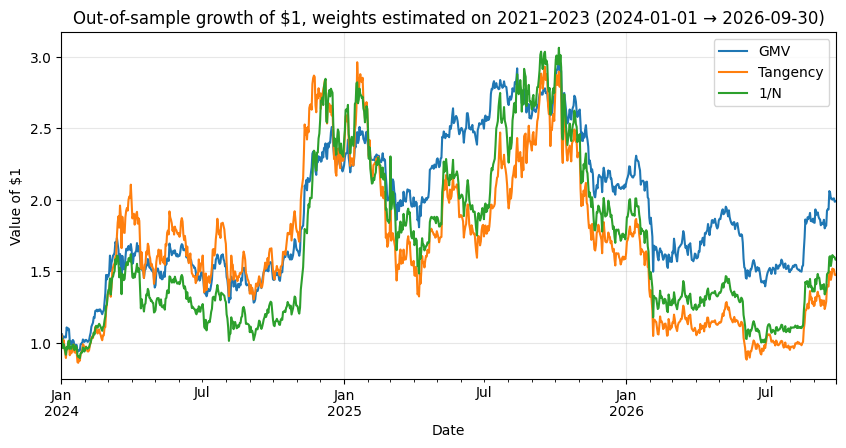

In [12]:
split = "2024-01-01"
r_in, r_out = returns.loc[:"2023-12-31"], returns.loc[split:]
mu_in, cov_in = r_in.mean().values * ANN, r_in.cov().values * ANN

portfolios = {"GMV": gmv_weights(cov_in), "Tangency": tangency_weights(mu_in, cov_in), "1/N": w0}


def realized(daily):
    ann_ret = daily.mean() * ANN
    ann_vol = daily.std() * np.sqrt(ANN)
    wealth = (1 + daily).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()
    return ann_ret, ann_vol, (ann_ret - RF) / ann_vol, max_dd


rows, curves = [], {}
for label, w in portfolios.items():
    pred_ret, pred_vol, pred_sharpe = port_stats(w, mu_in, cov_in)
    daily = r_out @ w
    curves[label] = (1 + daily).cumprod()
    ret, vol, sharpe, dd = realized(daily)
    rows.append([label, pred_ret, ret, pred_vol, vol, pred_sharpe, sharpe, dd])

table = pd.DataFrame(rows, columns=["Portfolio", "Pred. μ", "Real. μ", "Pred. σ", "Real. σ",
                                    "Pred. Sharpe", "Real. Sharpe", "Max drawdown"]).set_index("Portfolio")
display(table.style.format({c: "{:.1%}" for c in table.columns if "Sharpe" not in c} |
                           {"Pred. Sharpe": "{:.2f}", "Real. Sharpe": "{:.2f}"}))

in_weights = pd.DataFrame(portfolios, index=names)
display(in_weights.style.format("{:.1%}"))

ax = pd.DataFrame(curves).plot(figsize=(10, 4.5), lw=1.5)
ax.set_title(f"Out-of-sample growth of $1, weights estimated on 2021–2023 ({r_out.index[0].date()} → {r_out.index[-1].date()})")
ax.set_ylabel("Value of $1")
plt.show()

Three things stand out:

* **The tangency portfolio's promise collapsed.** Estimated on 2021–2023 it was about two-thirds SOL and predicted a 209% annual mean return with a Sharpe ratio of 1.80. From 2024 on it delivered 39% with a Sharpe of 0.50 and a 70% maximum drawdown. Its in-sample Sharpe was mostly SOL's exceptional 2021–2023 run, which did not repeat.
* **GMV delivered roughly what it promised.** It predicted a 34% mean and delivered 36%; it was the only portfolio whose realized Sharpe (0.68) beat its prediction, and it had the shallowest drawdown (−53%). Because it ignores $\hat\mu$, it is immune to the error that sank the tangency portfolio — though here it is essentially "hold BTC".
* **1/N landed in between.** Naive equal weighting, which estimates nothing at all, matched the tangency portfolio's out-of-sample Sharpe (0.52 vs 0.50) with a smaller drawdown — the DeMiguel, Garlappi & Uppal (2009) result in miniature.

This is a single split on eight highly correlated assets, so it is an illustration rather than proof; a rolling walk-forward test over many windows would be the next step.

## 9. Takeaways

1. **Mean-variance is about the trade-off, not either number alone.** A portfolio's mean is a weighted average of its assets' means, but its variance depends on every pairwise covariance — which is where diversification comes from.
2. **Diversification is limited by correlation.** Crypto assets are strongly correlated with each other, so combining them reduces risk far less than combining, say, equities and bonds would.
3. **The efficient frontier is exact only for the inputs you give it.** The closed-form and long-only frontiers are mathematically correct for the estimated $\mu$ and $\Sigma$; they say nothing about whether those estimates are right.
4. **Means are the weak link.** GMV, which ignores expected returns, is far more stable under resampling than the tangency portfolio, which relies on them.
5. **In-sample Sharpe ratios overstate what you will get.** Common fixes include shrinking the covariance (Ledoit–Wolf), shrinking or replacing the means (Black–Litterman), resampled frontiers (Michaud), weight caps, or risk-based methods that skip $\mu$ altogether (minimum variance, risk parity, HRP — see W1/HierarchicalRiskParity).

## References

* Markowitz, H. (1952). Portfolio Selection. *Journal of Finance* 7(1), 77–91.
* Merton, R. C. (1972). An Analytic Derivation of the Efficient Portfolio Frontier. *Journal of Financial and Quantitative Analysis* 7(4), 1851–1872.
* Tobin, J. (1958). Liquidity Preference as Behavior Towards Risk. *Review of Economic Studies* 25(2), 65–86.
* Michaud, R. O. (1989). The Markowitz Optimization Enigma: Is 'Optimized' Optimal? *Financial Analysts Journal* 45(1), 31–42.
* DeMiguel, V., Garlappi, L., Uppal, R. (2009). Optimal Versus Naive Diversification. *Review of Financial Studies* 22(5), 1915–1953.